# Análisis bivariado de datos

El análisis bivariado constituye el puente fundamental entre la descripción univariada de datos y el modelado estadístico o inferencial avanzado. Mientras que el análisis univariado permite caracterizar el comportamiento aislado de cada variable (su tendencia central, dispersión y forma de distribución), resulta insuficiente para comprender la complejidad inherente a los fenómenos reales, donde los factores rara vez operan de manera independiente.

Vamos a trabajar con el dataset **adult.data**, cuyo diccionario de datos se puede consultar en la página de [UC Irvine](https://archive.ics.uci.edu/dataset/2/adult).

In [2]:
import pandas as pd

df = pd.read_csv(
    "http://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
    header=None,
    names=['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship',
           'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'],
    na_values=' ?'
)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [5]:
df.describe(include='object')

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
count,30725,32561,32561,30718,32561,32561,32561,31978,32561
unique,8,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


## Análisis univariados

### Variables cuantitativas

In [4]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


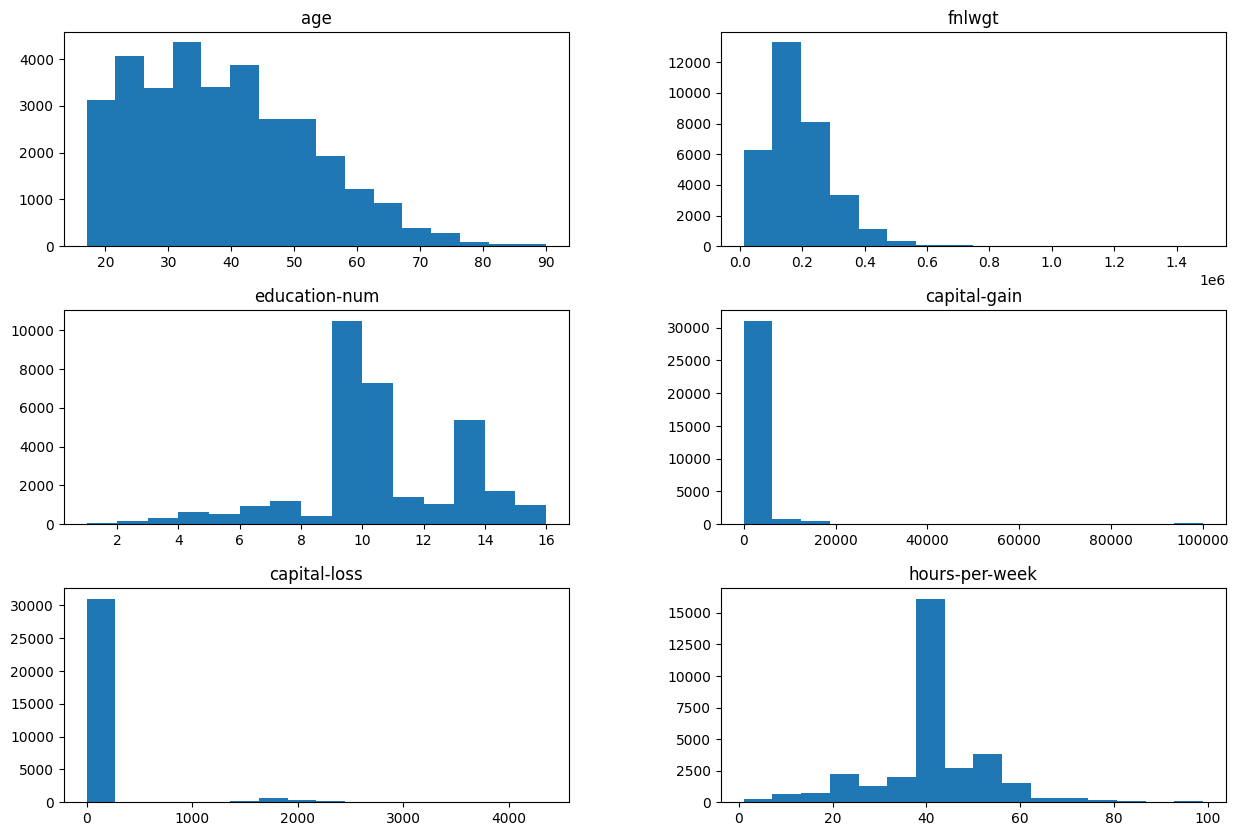

In [7]:
df.hist(figsize=(15, 10), bins='sturges',grid=False);

In [8]:
for num in df.select_dtypes(include=['number']).columns:
    print(f"Asimetría de {num}: {df[num].skew():.3f} \n")

Asimetría de age: 0.559 

Asimetría de fnlwgt: 1.447 

Asimetría de education-num: -0.312 

Asimetría de capital-gain: 11.954 

Asimetría de capital-loss: 4.595 

Asimetría de hours-per-week: 0.228 



In [9]:
for num in df.select_dtypes(include=['number']).columns:
    print(f"Kurtosis de {num}: {df[num].kurt():.3f} \n")

Kurtosis de age: -0.166 

Kurtosis de fnlwgt: 6.219 

Kurtosis de education-num: 0.623 

Kurtosis de capital-gain: 154.799 

Kurtosis de capital-loss: 20.377 

Kurtosis de hours-per-week: 2.917 



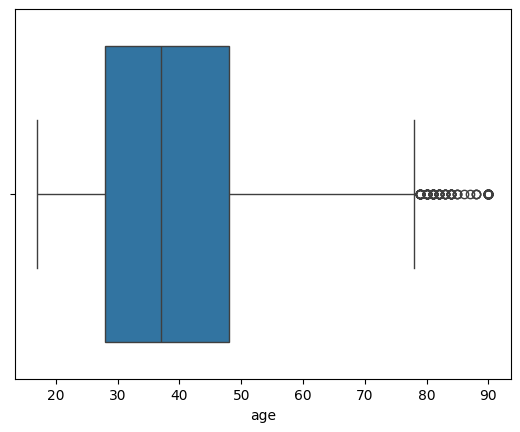

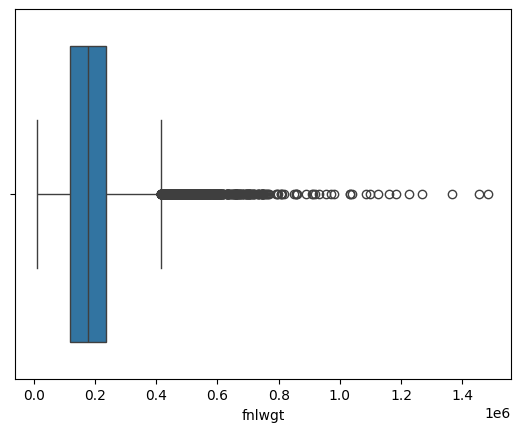

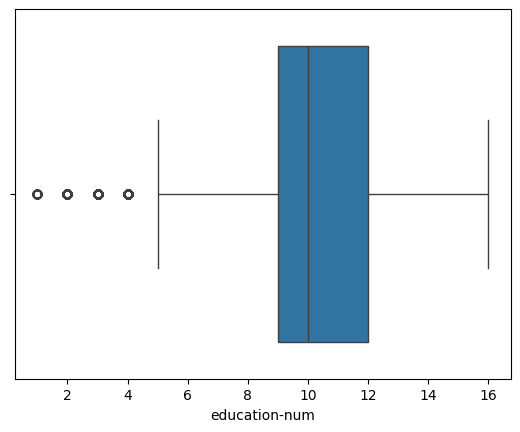

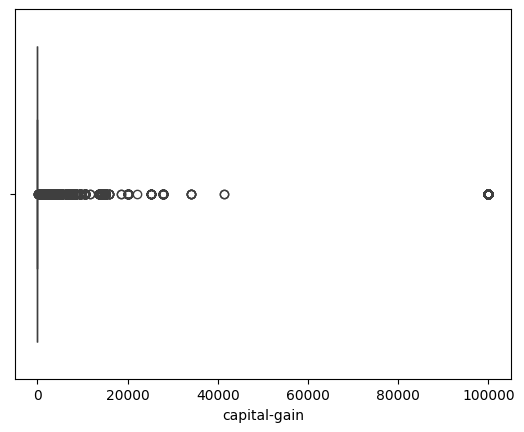

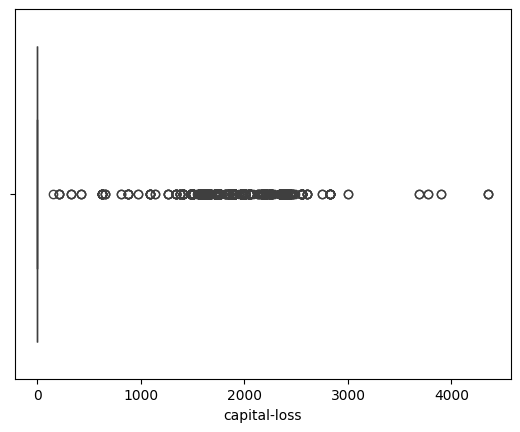

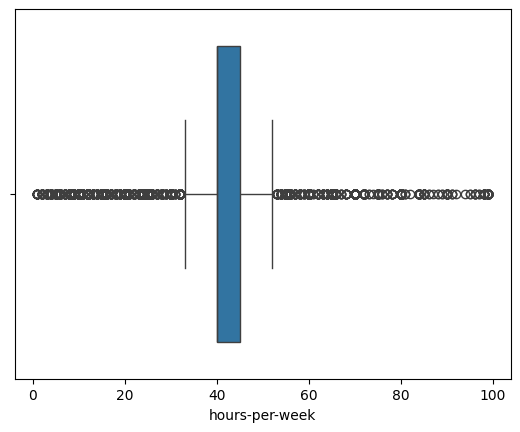

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

for num in df.select_dtypes(include=['number']).columns:
    plt.figure()
    sns.boxplot(data=df, x=num)
    plt.show();

### Variables categóricas

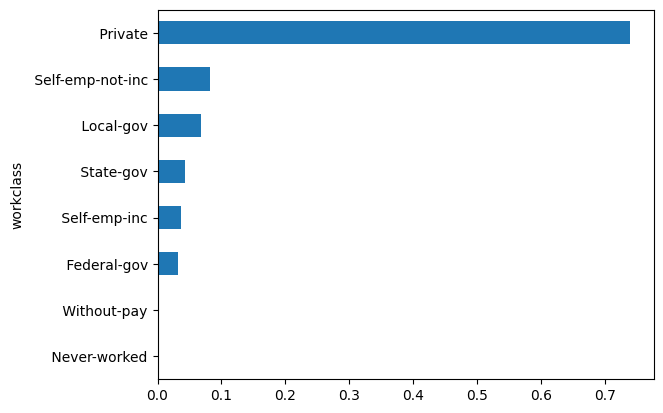

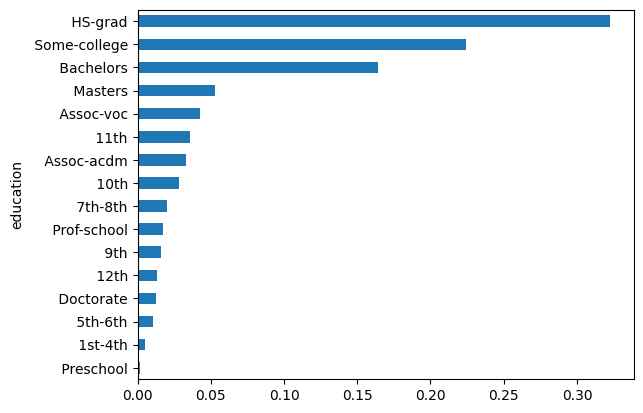

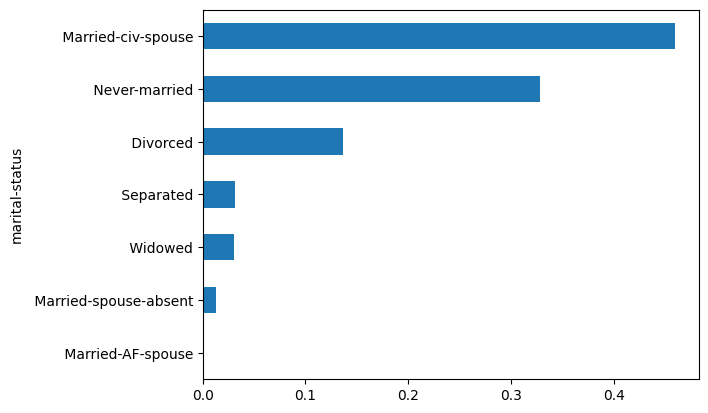

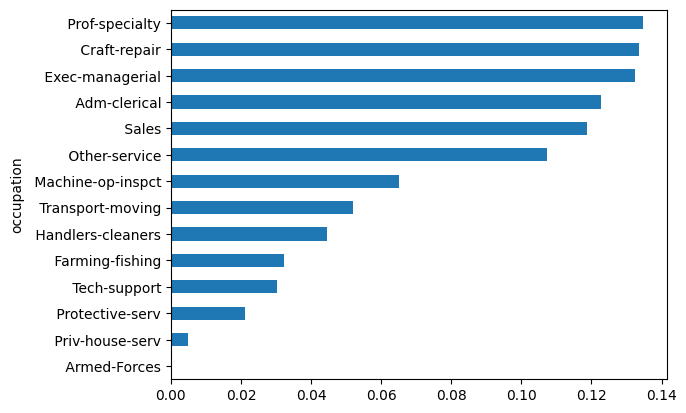

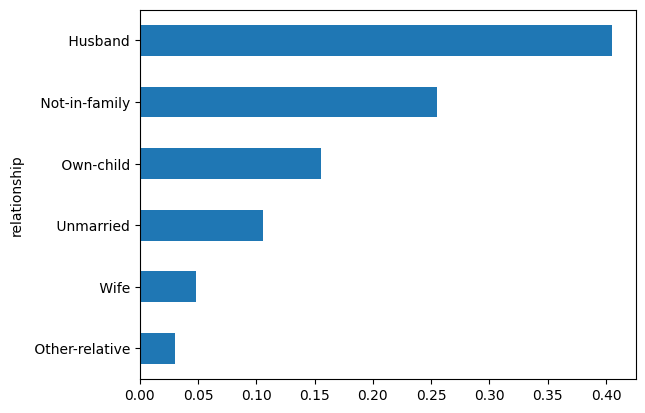

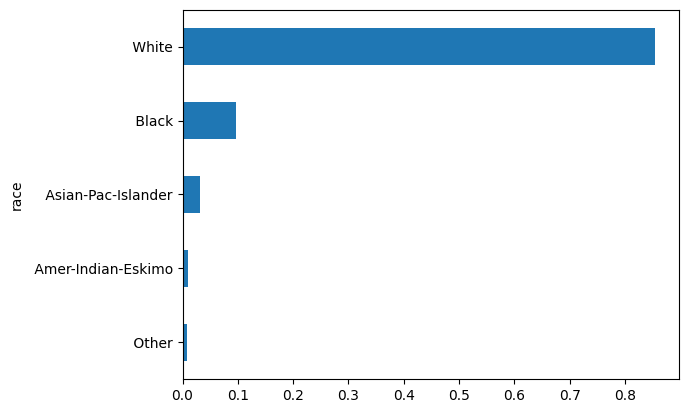

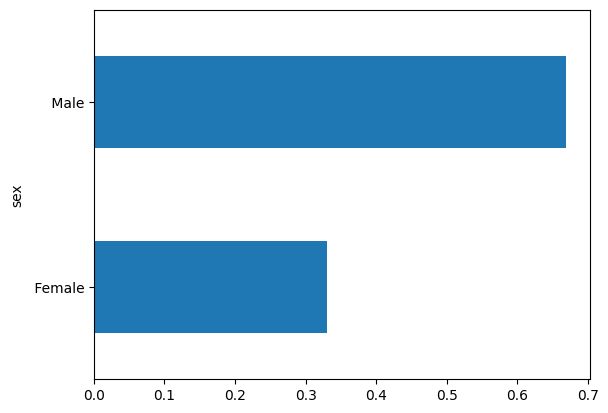

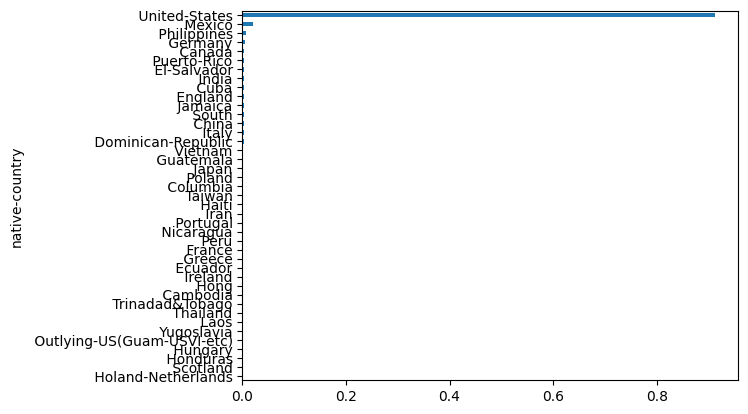

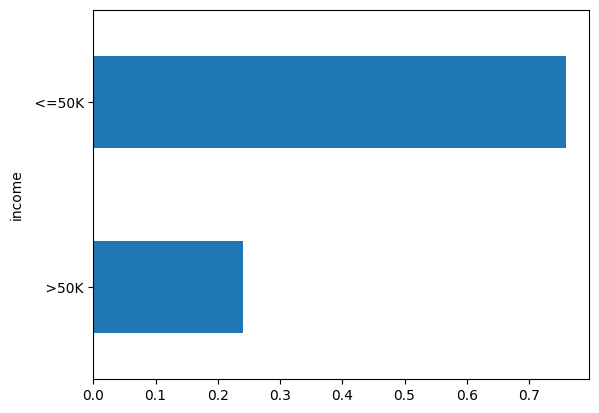

In [13]:
for cat in df.select_dtypes(include=['object']).columns:
  plt.figure()
  df[cat].value_counts(normalize=True, ascending=True).plot.barh()
  plt.show();

## Análisis bivariado

Los análisis univariados nos dan información sobre cada variable por separado, pero los datos rara vez existen de forma aislada. Las relaciones entre variables son clave para:

1. Identificar correlaciones y dependencias: ¿Cómo se relacionan dos variables numéricas? (ej. precio vs. tamaño) ¿Hay multicolinealidad que afecte modelos predictivos?
2. Detectar patrones y tendencias: ¿el ingreso promedio varía según el nivel educativo y la edad?
3. Encontrar interacciones y segmentaciones: Útil para segmentar clientes, entender perfiles o clasificar comportamientos.
4. Prevenir interpretaciones erróneas: Una variable puede parecer importante sola, pero perder relevancia al considerar otras.

En resumen, el análisis bivariado permite entender la estructura y relaciones en el conjunto de datos, no solo en variables aisladas.

### Relaciones entre dos variables numéricas:

Las relaciones entre variables numéricas se pueden **observar** mediante gráficos de dispersión, o medir mediante la función de correlación.

Por ejemplo, veamos si hay alguna relación entre las variables **age** y **hours-per-week**:

<Axes: xlabel='age', ylabel='hours-per-week'>

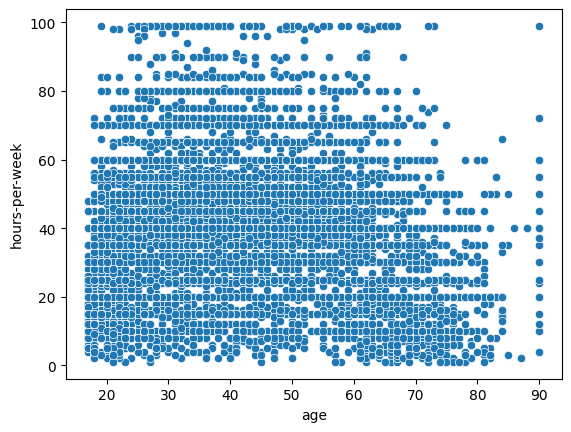

In [14]:
sns.scatterplot(data=df, x='age', y='hours-per-week')

¿Qué se observa?

En Seaborn, la función `pairplot()`permite generar los gráficos de dispersión de todos los pares de variables cuantitativas:

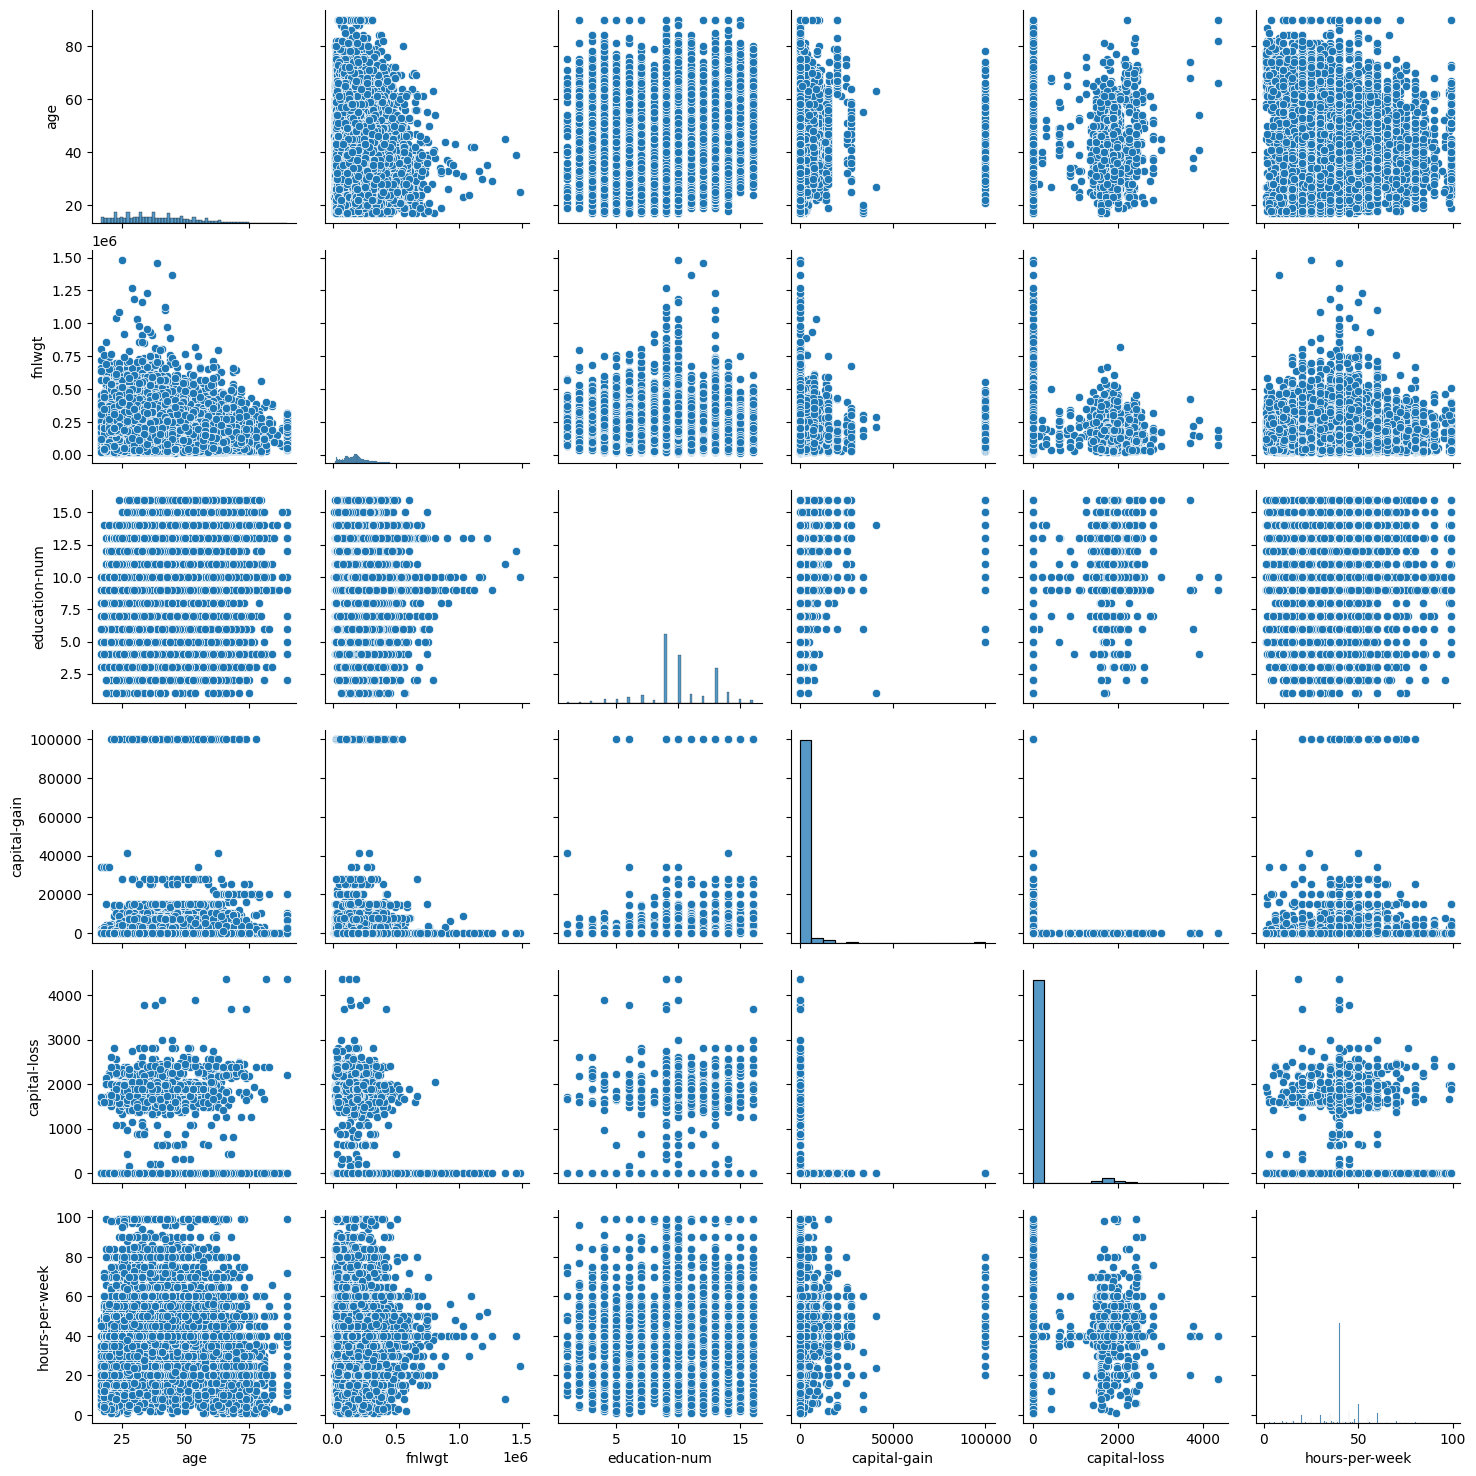

In [15]:
sns.pairplot(df.select_dtypes(include=['number']))

Por otra parte, la **función de correlación** mide el grado de relación entre dos variables, indicando cómo una variable cambia en función de otra. Se utiliza ampliamente en estadística y análisis de señales para identificar patrones y dependencias entre datos. En términos matemáticos, la correlación se calcula como la normalización de la covarianza, lo que permite obtener valores entre **-1 y 1**: un valor cercano a **1** indica una correlación positiva fuerte (ambas variables aumentan o disminuyen juntas), un valor cercano a **-1** indica una correlación negativa fuerte (una variable aumenta mientras la otra disminuye), y un valor cercano a **0** sugiere que no hay una relación lineal entre ellas. En aplicaciones como el análisis de datos, series temporales y procesamiento de señales, la función de correlación ayuda a detectar patrones ocultos, evaluar redundancia de datos y seleccionar variables relevantes para modelos predictivos.

In [16]:
corr = df.select_dtypes('number').corr(method='pearson')
corr

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756
fnlwgt,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768
education-num,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123
capital-gain,0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409
capital-loss,0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256
hours-per-week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000


Las correlaciones entre variables se interpretan mejor usando **mapas de calor**:

<Axes: >

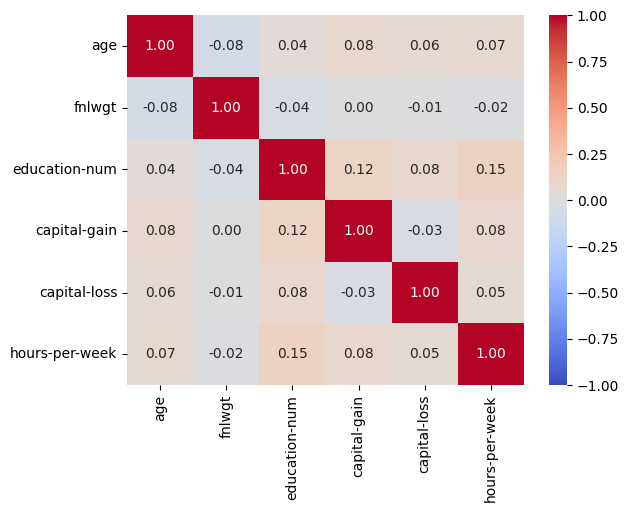

In [17]:
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)

### Relaciones entre una variable cualitativa y una cuantitativa

En este caso, lo que se intenta encontrar es si el comportamiento de la variable numérica **depende** de las categorías de la variable categórica, esto es, sí se observan diferencias entre categorías.

Este tipo de análisis se suele hacer utilizando gráficos de cajas agrupados, histogramas o gráficos de densidad agrupados, o analizando las estadísticas descriptivas de la variable numérica **agrupada** por categorías de la variable categórica, usando la función `groupby()`.

Por ejemplo, vamos a evaluar si la variable **age** depende de **income**:

In [20]:
df.groupby('income')['age'].describe().T

income,<=50K,>50K
count,24720.000000,7841.000000
mean,36.783738,44.249841
std,14.020088,10.519028
min,17.000000,19.000000
25%,25.000000,36.000000
50%,34.000000,44.000000
75%,46.000000,51.000000
max,90.000000,90.000000


<Axes: xlabel='age', ylabel='income'>

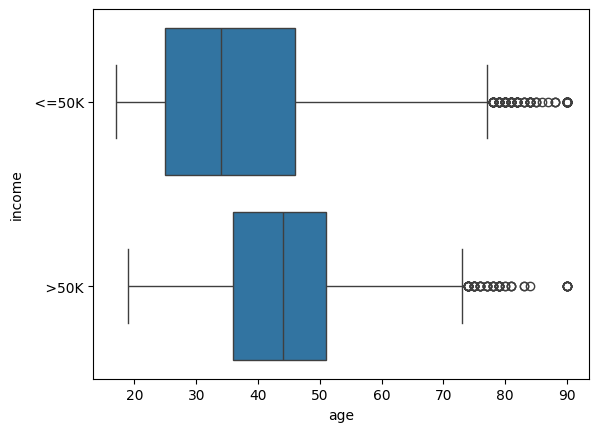

In [18]:
sns.boxplot(data=df, y='income', x='age')

<Axes: xlabel='age', ylabel='Density'>

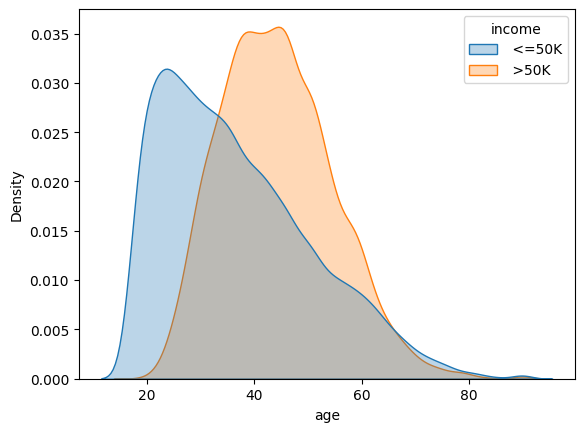

In [19]:
sns.kdeplot(data=df, x='age', hue='income', fill=True, alpha=0.3, common_norm=False)

In [22]:
import numpy as np

col_num='age'
col_cat='income'

def calcular_eta_cuadrado(df, col_cat, col_num):
    y = df[col_num].dropna()
    grupos = df.groupby(col_cat)[col_num]

    media_global = y.mean()
    sct = np.sum((y - media_global) ** 2)

    # SCE = suma de n_j * (media_j - media_global)^2
    sce = np.sum(grupos.count() * (grupos.mean() - media_global) ** 2)

    eta_2 = sce / sct
    eta = np.sqrt(eta_2)
    return eta_2, eta

eta2_val, eta_val = calcular_eta_cuadrado(df, col_cat, col_num)
print(f"\nEta cuadrado (eta^2): {eta2_val:.4f} (Explica el {eta2_val*100:.2f}% de la varianza)")
print(f"Razón de correlación (eta): {eta_val:.4f}")


Eta cuadrado (eta^2): 0.0548 (Explica el 5.48% de la varianza)
Razón de correlación (eta): 0.2340


### Relaciones entre variables categóricas

Los análisis entre variables categóricas se pueden hacer usando tablas de contingencia, mapas de calor, o gráficos de barras agrupados o apilados, preferiblemente en proporciones.

Las tablas de contingencia muestran la distribución **conjunta** de dos o más variables categóricas. En **Pandas** se pueden hacer mediante la función `crosstab()`

In [23]:
tabla = pd.crosstab(df['sex'], df['income'], margins=True)
tabla

income,<=50K,>50K,All
sex,,,
Female,9592,1179,10771
Male,15128,6662,21790
All,24720,7841,32561


Estas tablas se pueden normalizar para ver las **proporciones**:

In [24]:
tabla = pd.crosstab(df['sex'], df['income'], normalize='index', margins=True)
tabla

income,<=50K,>50K
sex,,
Female,0.890539,0.109461
Male,0.694263,0.305737
All,0.759190,0.240810


In [25]:
tabla = 100*pd.crosstab(df['sex'], df['income'], normalize='columns', margins=True).round(4)
tabla

income,<=50K,>50K,All
sex,,,
Female,38.8,15.04,33.08
Male,61.2,84.96,66.92


In [26]:
tabla = 100*pd.crosstab(df['sex'], df['income'], normalize='all', margins= True).round(4)
tabla

income,<=50K,>50K,All
sex,,,
Female,29.46,3.62,33.08
Male,46.46,20.46,66.92
All,75.92,24.08,100.00


In [29]:
from scipy.stats import chi2_contingency

tabla = pd.crosstab(df['sex'], df['income'])

# 3. Cálculo de Chi-cuadrado y V de Cramér
chi2, p_val, dof, expected = chi2_contingency(tabla, correction=False)

n = df.shape[0]
r, c = tabla.shape

v_cramer = np.sqrt(chi2 / (n * min(r - 1, c - 1)))

phi = np.sqrt(chi2 / n)
print(f"Coeficiente Phi (magnitud): {phi:.4f}")

print(f"Chi2: {chi2:.2f} | V de Cramer: {v_cramer:.4f}")

Coeficiente Phi (magnitud): 0.2160
Chi2: 1518.89 | V de Cramer: 0.2160


Se pueden usar mapas de calor para visualizar las tablas de contingencia:

<Axes: xlabel='income', ylabel='sex'>

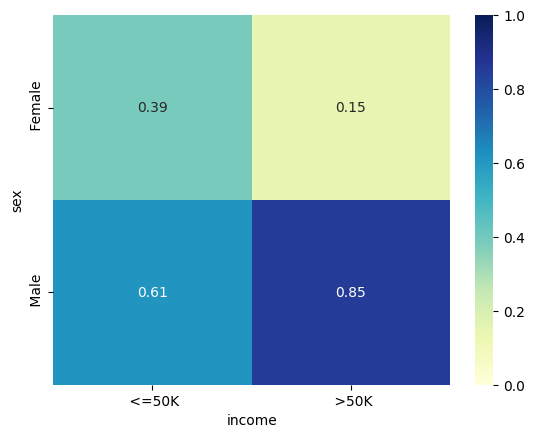

In [30]:
tabla = pd.crosstab(df['sex'], df['income'], normalize='columns')
sns.heatmap(tabla, annot=True, fmt='.2f', vmin=0, vmax=1, cmap='YlGnBu')

Por último, se pueden usar gráficos de barras apilados o agrupados:

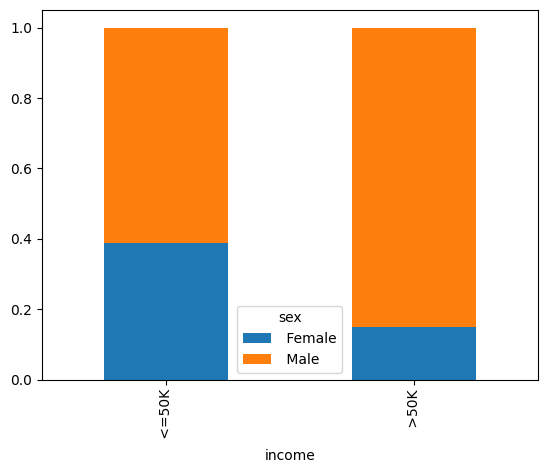

In [31]:
tabla = pd.crosstab(df['income'], df['sex'], normalize='index')
tabla.plot.bar(stacked=True);

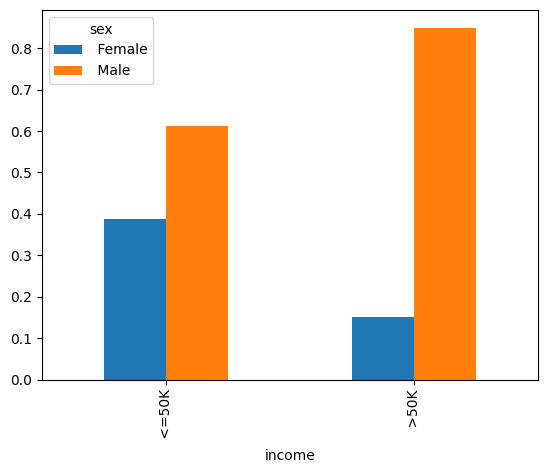

In [32]:
tabla.plot.bar(stacked=False);